# Ejercicio Geo visualizacion

 - Importa el csv house_pricing.csv
 - Realiza primero un tratamiento de datos: gestiona los valores nulos, crea nuevas variables que te faciliten el posterior análisis exploratorio como tamaño_casa(Casa pequeña, media, grande, mansión), o precio_catagorizado (barato, normal, caro)... Puedes usar más de una variable para definirlas como el número de baños, pisos o simplemente los _square feet_
 - Utiliza las variables lat y long para dibujar las viviendas en en el mapa
   - Primero con `geopandas`
   - A continuación con `kepler`
 - Perfecciona tus visualizaciones añadiendo detalles como tamaño de los puntos o sus colores en función de el resto de variables, como el precio o el tamaño u otras que hayas creado anteriormente

Feature Description:

 - id: Unique identifier for each property.
 - date: Date of sale.
 - price: Sale price of the house.
 - bedrooms: Number of bedrooms.
 - bathrooms: Number of bathrooms (including partials as fractions).
 - sqft_living: Living space area in square feet.
 - sqft_lot: Lot size in square feet.
 - floors: Number of floors.
 - waterfront: Whether the property has a waterfront view.
 - view: Quality of the view rating.
 - condition: Overall condition of the house.
 - grade: Grade of construction and design (scale of 1–13).
 - sqft_above: Square footage of the property above ground.
 - sqft_basement: Basement area in square feet.
 - yr_built: Year the property was built.
 - yr_renovated: Year of last renovation.
 - zipcode: ZIP code of the property.
 - lat and long: Latitude and longitude coordinates.
 - sqft_living15: Average living space of 15 nearest properties.
 - sqft_lot15: Average lot size of 15 nearest properties.

In [40]:
import pandas as pd
from keplergl import KeplerGl
import seaborn as sns
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.max_columns',None) 
# import matplotlib.pyplot as plt
# from shapely.geometry import Point

In [39]:
df = pd.read_csv('/Users/aliciakmak/Desktop/DataScience/DS_Consorci_2025/Data/House Pricing.csv', sep = ';')
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   date           21597 non-null  object 
 2   bedrooms       21597 non-null  int64  
 3   bathrooms      21597 non-null  float64
 4   sqft_living    21597 non-null  int64  
 5   sqft_lot       21597 non-null  int64  
 6   floors         21597 non-null  float64
 7   waterfront     21597 non-null  int64  
 8   view           21597 non-null  int64  
 9   condition      21597 non-null  int64  
 10  grade          21597 non-null  int64  
 11  sqft_above     21597 non-null  int64  
 12  sqft_basement  21597 non-null  int64  
 13  yr_built       21597 non-null  int64  
 14  yr_renovated   21597 non-null  int64  
 15  zipcode        21597 non-null  int64  
 16  lat            21597 non-null  float64
 17  long           21597 non-null  float64
 18  sqft_l

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price
count,21597,21597,21597,21597,21597,21597,21597,21597,21597,21597,21597,21597,21597,21597,21597,21597,21597,21597,21597,21597
mean,4580474288,3,2,2080,15099,1,0,0,3,8,1789,292,1971,84,98078,48,-122,1987,12758,540297
std,2876735716,1,1,918,41413,1,0,1,1,1,828,443,29,402,54,0,0,685,27274,367368
min,1000102,1,0,370,520,1,0,0,1,3,370,0,1900,0,98001,47,-123,399,651,78000
25%,2123049175,3,2,1430,5040,1,0,0,3,7,1190,0,1951,0,98033,47,-122,1490,5100,322000
50%,3904930410,3,2,1910,7618,2,0,0,3,7,1560,0,1975,0,98065,48,-122,1840,7620,450000
75%,7308900490,4,2,2550,10685,2,0,0,4,8,2210,560,1997,0,98118,48,-122,2360,10083,645000
max,9900000190,33,8,13540,1651359,4,1,4,5,13,9410,4820,2015,2015,98199,48,-121,6210,871200,7700000


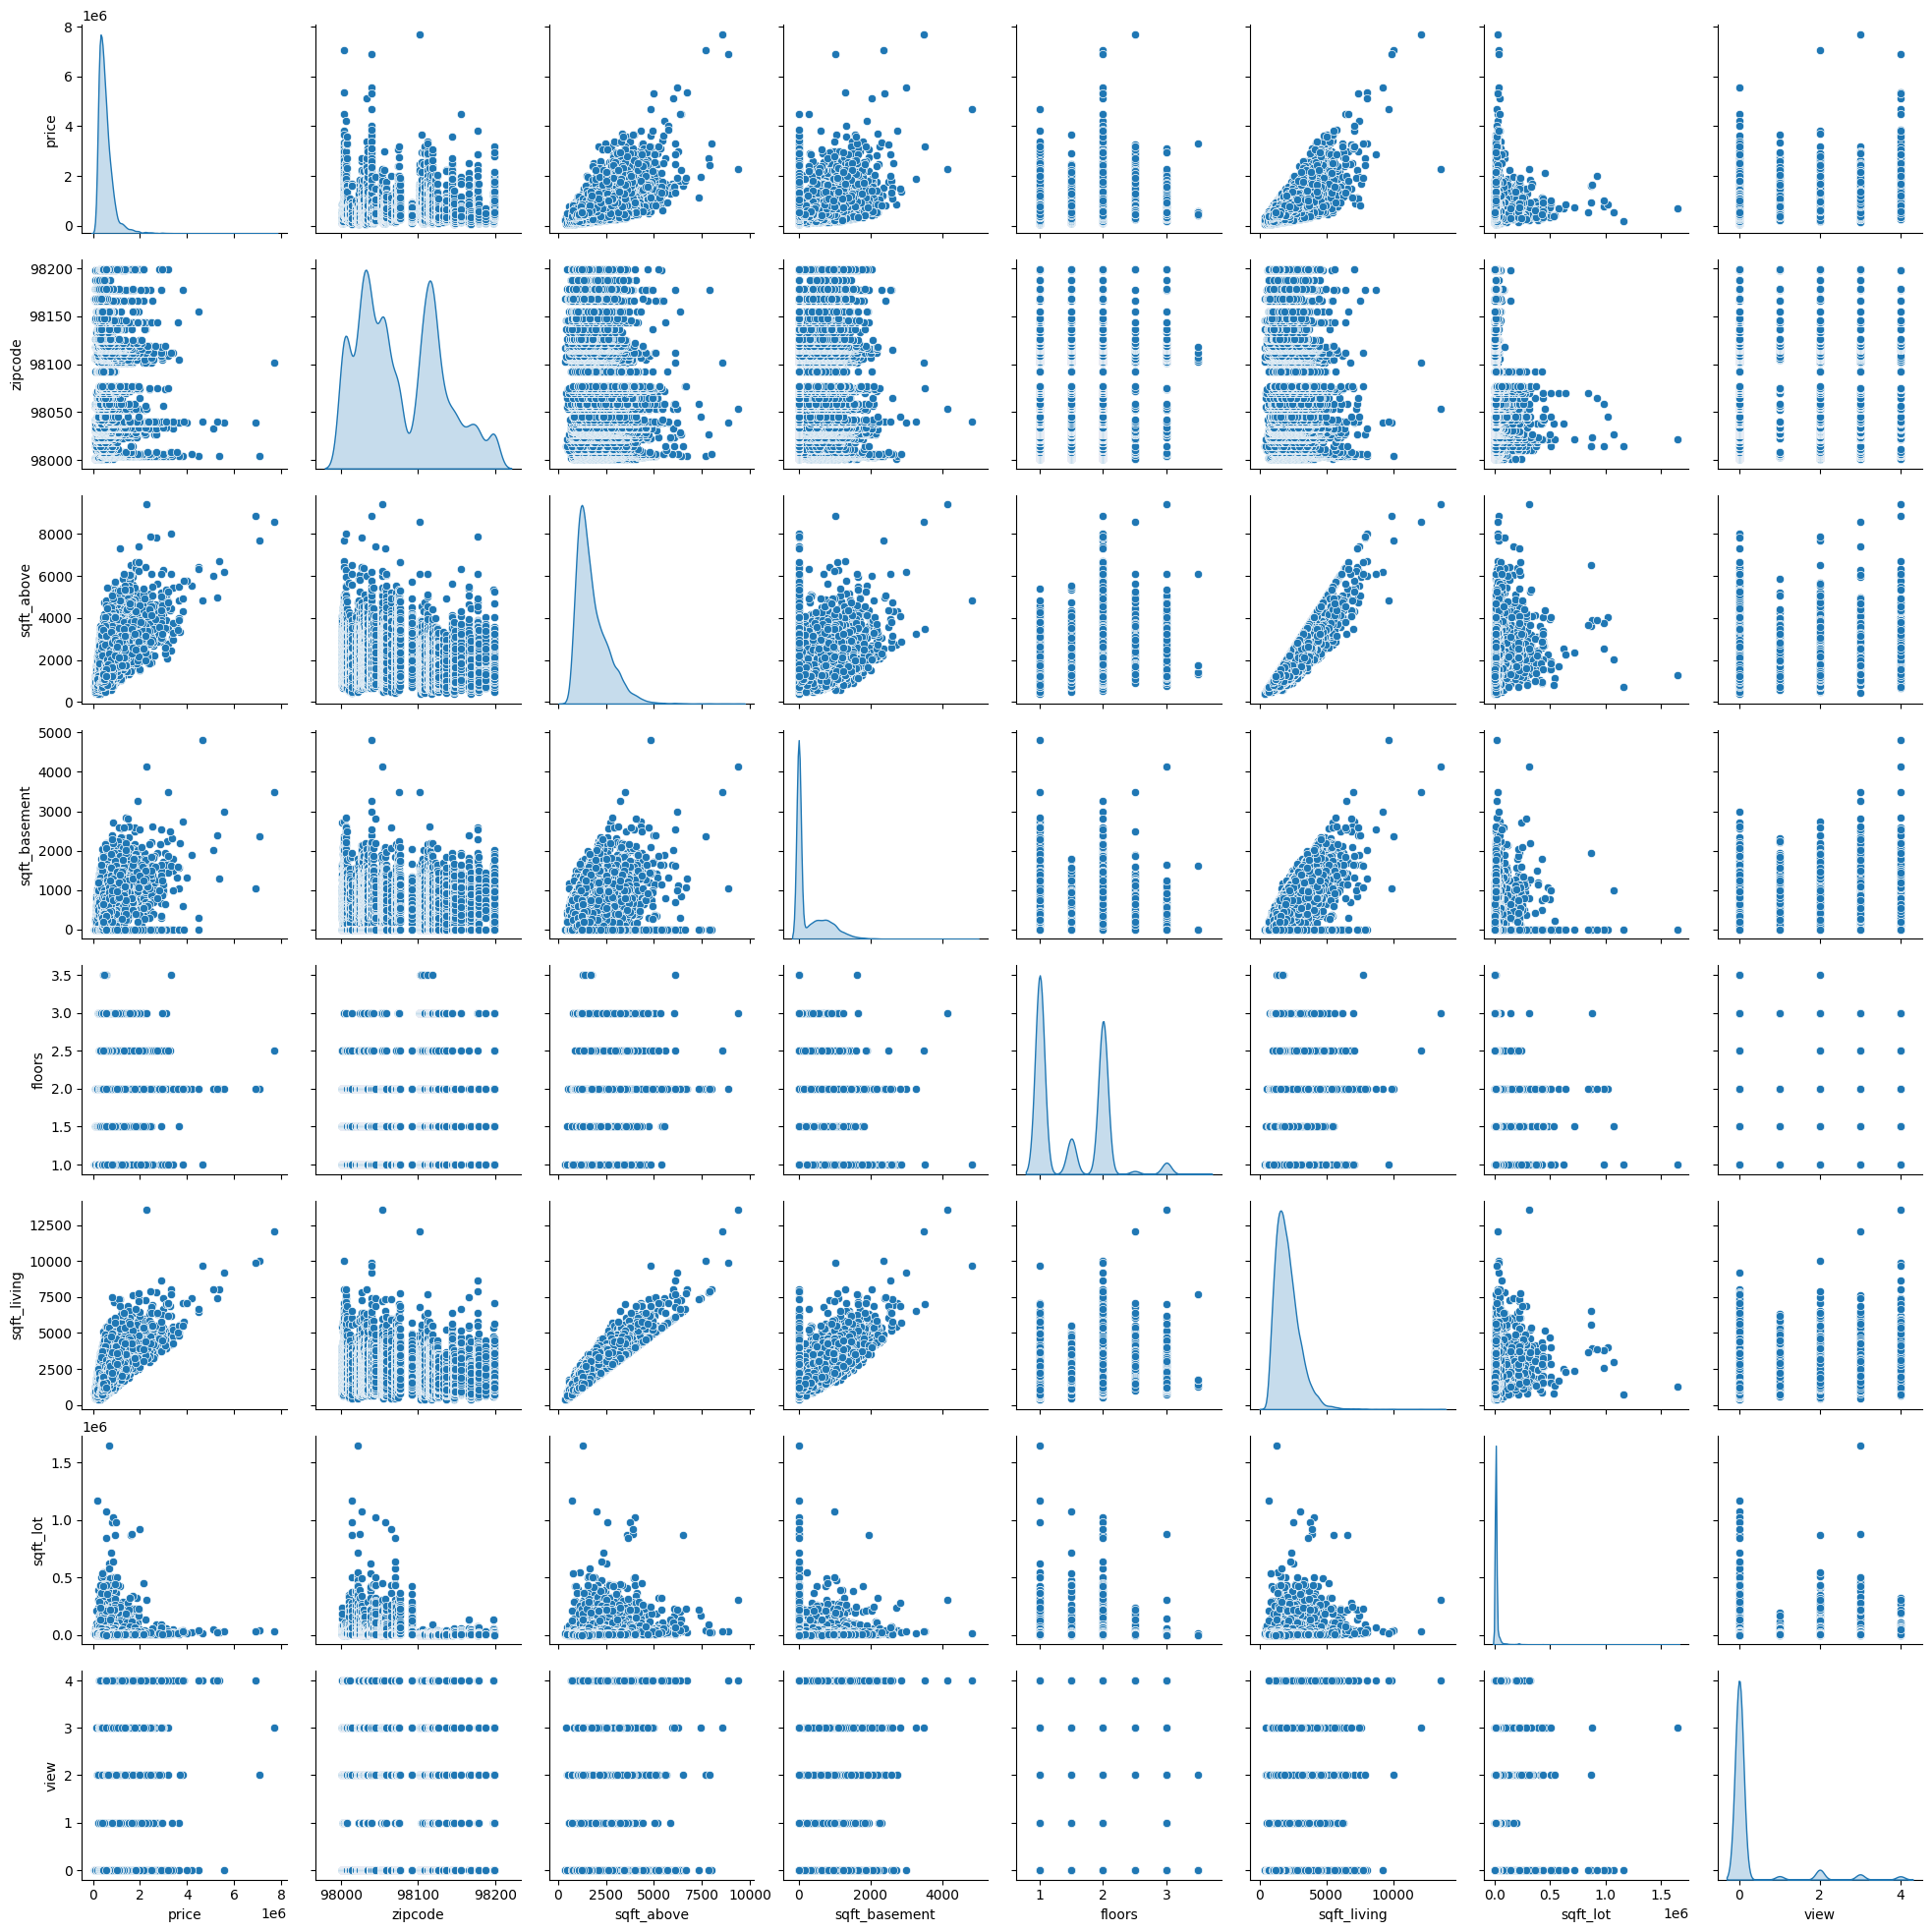

In [46]:

sns.pairplot(df[['price', 'zipcode', 'sqft_above', 'sqft_basement','floors', 'sqft_living', 'sqft_lot','view']], diag_kind='kde', markers=["o", "s"])


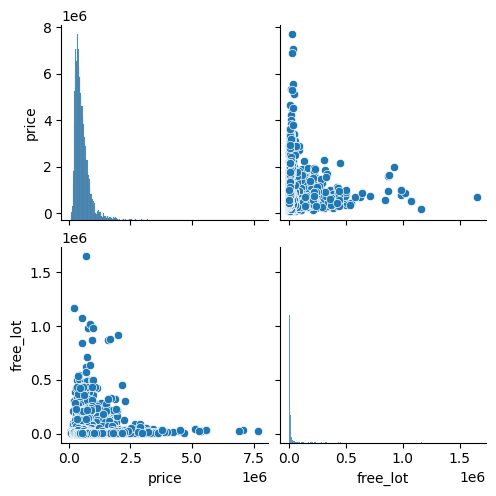

In [55]:
df['free_lot']=df['sqft_lot'] - (df['sqft_living']/df['floors'])
df['free_lot'].describe()
df.loc[df['free_lot']<0]
sns.pairplot(df[['price', 'free_lot']])

In [32]:
import matplotlib.pyplot as plt
import geopandas as gdp

# Create a very simple world map as background
world = gdp.read_file(gdp.datasets.get_path('naturalearth_lowres'))


# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Add a simple world map background
world.plot(ax=ax, color='lightgray', edgecolor='white')

# Plot the points directly on the map using matplotlib's scatter
scatter = ax.scatter(df['long'], df['lat'], 
                    c=df['price'],
                    cmap='coolwarm',
                    alpha=0.5,
                    s=5)

AttributeError: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.

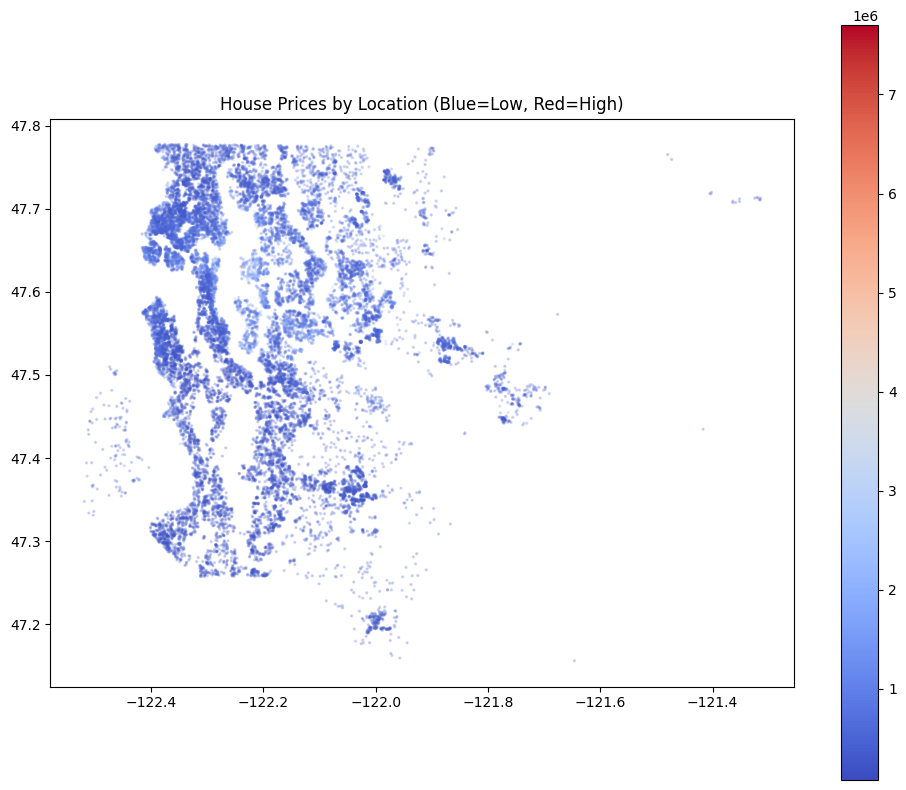

In [35]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Convert DataFrame to GeoDataFrame
# Create Point geometries from longitude and latitude
geometry = [Point(xy) for xy in zip(df['long'], df['lat'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry)

# Set coordinate reference system
gdf.crs = "EPSG:4326"

# Create a simple figure
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the points with blue-to-red color scheme
gdf.plot(column='price', 
         cmap='coolwarm',  # Blue to red color map
         legend=True,      # Include a legend
         ax=ax,           
         alpha=0.2,        # Semi-transparent points
         markersize=2)     # Small point size

# Add title
plt.title('House Prices by Location (Blue=Low, Red=High)')

# Show the plot
plt.tight_layout()
plt.show()

In [22]:
# Crear un mapa en Kepler.gl
mapa = KeplerGl(height=600)
mapa.add_data(data=df, name="precios viviendas")

# Mostrar el mapa
mapa

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


KeplerGl(data={'precios viviendas': {'index': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 1…

In [7]:
df.waterfront.value_counts()

0    21434
1      163
Name: waterfront, dtype: int64